# PCA (Principal Component Analysis)

PCA itself is NOT a Machine Learning model.

It's a preprocessing (feature engineering / dimensionality reduction) algorithm.

In [37]:
import numpy as np

# Data

In [38]:
#   height weight
# X = np.array([
#     [150, 45],
#     [160, 55],
#     [170, 65],
#     [180, 75],
#     [190, 85]
# ], dtype=float)


X = np.array([
    [170, 65,  80,  75,  85],
    [172, 68,  82,  78,  88],
    [168, 62,  75,  72,  80],
    [175, 72,  88,  82,  90],
    [180, 78,  92,  85,  95],
    [178, 75,  90,  84,  93],
    [165, 58,  70,  68,  76],
    [167, 60,  73,  70,  78],
    [173, 69,  84,  79,  87],
    [176, 73,  87,  81,  91]
])

# Mean

In [39]:
mean = np.mean(X, axis = 0)

print(mean)

[172.4  68.   82.1  77.4  86.3]


# varaince 

In [40]:
X_centered = X - mean

X_centered.T

array([[ -2.4,  -0.4,  -4.4,   2.6,   7.6,   5.6,  -7.4,  -5.4,   0.6,
          3.6],
       [ -3. ,   0. ,  -6. ,   4. ,  10. ,   7. , -10. ,  -8. ,   1. ,
          5. ],
       [ -2.1,  -0.1,  -7.1,   5.9,   9.9,   7.9, -12.1,  -9.1,   1.9,
          4.9],
       [ -2.4,   0.6,  -5.4,   4.6,   7.6,   6.6,  -9.4,  -7.4,   1.6,
          3.6],
       [ -1.3,   1.7,  -6.3,   3.7,   8.7,   6.7, -10.3,  -8.3,   0.7,
          4.7]])

# Covariance Matrix

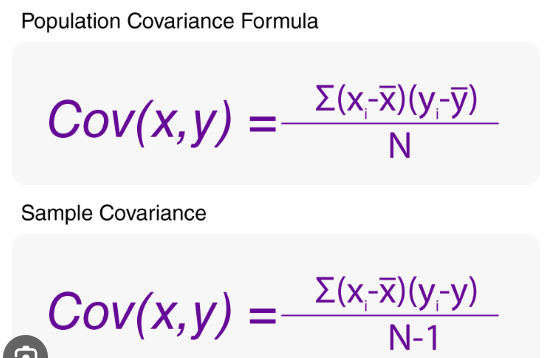

Same Formula but in matrix directly

### Numpy version

In [41]:
np.cov(X_centered.T)

array([[24.26666667, 32.77777778, 36.51111111, 28.82222222, 31.31111111],
       [32.77777778, 44.44444444, 49.66666667, 39.22222222, 42.66666667],
       [36.51111111, 49.66666667, 56.32222222, 44.4       , 48.07777778],
       [28.82222222, 39.22222222, 44.4       , 35.15555556, 37.97777778],
       [31.31111111, 42.66666667, 48.07777778, 37.97777778, 41.78888889]])

### My version

In [42]:
n = X_centered.shape[0]

# @ -> dot product
cov_matrix = (X_centered.T @ X_centered) / (n - 1)

cov_matrix

array([[24.26666667, 32.77777778, 36.51111111, 28.82222222, 31.31111111],
       [32.77777778, 44.44444444, 49.66666667, 39.22222222, 42.66666667],
       [36.51111111, 49.66666667, 56.32222222, 44.4       , 48.07777778],
       [28.82222222, 39.22222222, 44.4       , 35.15555556, 37.97777778],
       [31.31111111, 42.66666667, 48.07777778, 37.97777778, 41.78888889]])

# Eigenvalues & Eigenvectors

### Numpy version

In [43]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues")
print(eigenvalues)

print()

print("Eigenvectors")
print(eigenvectors)

Eigenvalues
[2.00640031e+02 7.23335507e-01 2.90690027e-02 9.51218578e-02
 4.90220179e-01]

Eigenvectors
[[-3.45564324e-01  6.36756029e-01 -6.87615687e-01  4.67277631e-02
   1.13243401e-02]
 [-4.69537626e-01  5.14077188e-01  7.09470685e-01 -5.96806408e-02
   9.13708401e-02]
 [-5.28749931e-01 -3.24161161e-01 -6.41647101e-04  6.15492049e-01
  -4.86325177e-01]
 [-4.17549598e-01 -2.70757191e-01 -1.00048507e-01 -7.83904974e-01
  -3.57527852e-01]
 [-4.54087612e-01 -3.89713342e-01 -1.17583581e-01  3.02864161e-02
   7.91949990e-01]]


In [44]:
#      sort and give index   # rev it so we get descending order
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]

eigenvectors = eigenvectors[:, idx]

print("Eigenvalues")
print(eigenvalues)

print()

print("Eigenvectors")
print(eigenvectors)

Eigenvalues
[2.00640031e+02 7.23335507e-01 4.90220179e-01 9.51218578e-02
 2.90690027e-02]

Eigenvectors
[[-3.45564324e-01  6.36756029e-01  1.13243401e-02  4.67277631e-02
  -6.87615687e-01]
 [-4.69537626e-01  5.14077188e-01  9.13708401e-02 -5.96806408e-02
   7.09470685e-01]
 [-5.28749931e-01 -3.24161161e-01 -4.86325177e-01  6.15492049e-01
  -6.41647101e-04]
 [-4.17549598e-01 -2.70757191e-01 -3.57527852e-01 -7.83904974e-01
  -1.00048507e-01]
 [-4.54087612e-01 -3.89713342e-01  7.91949990e-01  3.02864161e-02
  -1.17583581e-01]]


# Explained Variance Ratio

In [45]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

print("Explained Variance Ratio:")
print(explained_variance_ratio)

Explained Variance Ratio:
[9.93376764e-01 3.58126283e-03 2.42709958e-03 4.70952096e-04
 1.43921787e-04]


# Cumulative Explained Variance

In [46]:
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Cumulative Explained Variance:")
print(cumulative_variance)

Cumulative Explained Variance:
[0.99337676 0.99695803 0.99938513 0.99985608 1.        ]


# Choose k Automatically

In [47]:
threshold = 0.95

k = np.argmax(cumulative_variance >= threshold) + 1

print("Number of components:", k)

Number of components: 1


# Select the Principal Components

In [48]:
k = 2 # change this two get pca

principal_components = eigenvectors[:, :k]

print("Principal Components:")
print(principal_components)

Principal Components:
[[-0.34556432  0.63675603]
 [-0.46953763  0.51407719]
 [-0.52874993 -0.32416116]
 [-0.4175496  -0.27075719]
 [-0.45408761 -0.38971334]]


# Project the Data

In [49]:
X_pca = X_centered @ principal_components

print("Original shape:", X.shape)
print("PCA shape:", X_pca.shape)

Original shape: (10, 5)
PCA shape: (10, 2)


# Reconstruct the Data

In [50]:
X_reconstructed = X_pca @ principal_components.T + mean

print("Reconstructed data:")
print(X_reconstructed)

Reconstructed data:
[[169.90735677  65.04612784  79.8873415   75.67089619  84.5370743 ]
 [172.02044972  67.85199421  82.87906989  78.0306929   87.08564702]
 [168.04781889  61.96965213  75.00878481  71.79521105  80.17307132]
 [175.11635478  72.00269191  87.40947531  81.60596721  90.95861701]
 [180.04299755  77.92055792  92.07716405  85.25935143  94.72108919]
 [177.7824367   75.24129033  90.06896095  83.68999076  93.1208321 ]
 [165.11069105  57.8748416   70.1301789   67.93824145  75.95038595]
 [166.82984421  60.20785753  72.7499631   70.00694238  78.19932508]
 [173.05065075  69.03357728  83.64843302  78.62907393  87.67718685]
 [176.09139957  72.85140925  87.14062847  81.37363271  90.57677118]]


# Calc Error

In [51]:
reconstruction_error = np.mean(
    (X - X_reconstructed) ** 2
)

print("Reconstruction Error:", reconstruction_error)

Reconstruction Error: 0.11059398713621954


# Visualize

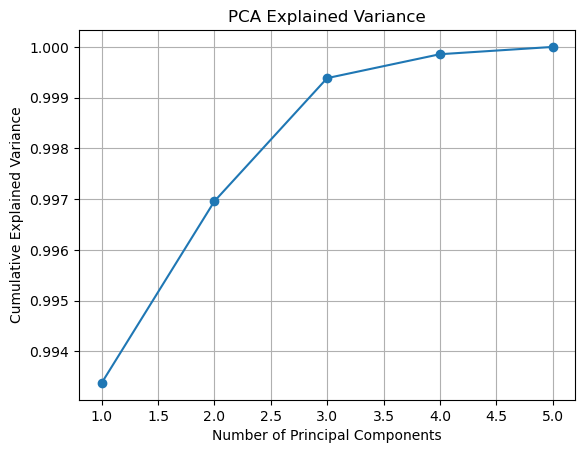

In [52]:
import matplotlib.pyplot as plt

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid()
plt.show()

# Origin data

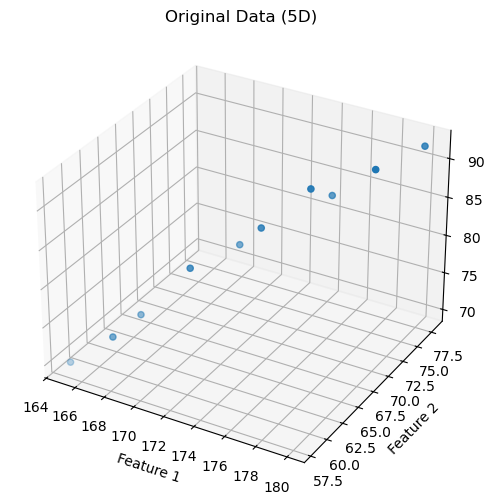

In [53]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X[:, 0],
    X[:, 1],
    X[:, 2]
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
ax.set_title("Original Data (5D)")

plt.show()

# Pca Data

In [54]:
X_pca

array([[  4.94077504,  -1.23326299],
       [ -0.83137798,  -1.04725329],
       [ 13.20735308,   0.33263748],
       [ -9.49709466,  -0.88809887],
       [-19.68022861,   1.32266147],
       [-15.1972624 ,   0.20542405],
       [ 22.25249505,   0.62874858],
       [ 17.29276693,   0.63699047],
       [ -2.66744177,  -0.42578625],
       [ -9.81998469,   0.46793935]])

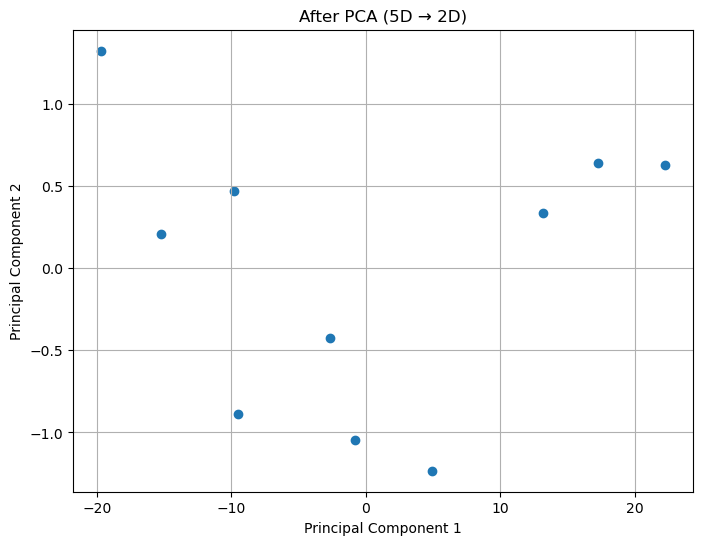

In [55]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("After PCA (5D → 2D)")

plt.grid()
plt.show()